## Imports



In [1]:
import torch
import matplotlib.pyplot as plt
import numpy as np
from tqdm.notebook import tqdm
from dataclasses import dataclass, field
from typing import List, Optional
import seaborn as sns
from performance_boosting import PBClosedLoop
from ren import ContractiveREN
from robot import RobotPlant, StabilizedRobot, PDController
from plot_functions import plot_pb_trajectories, plot_distance_tube
from dataset import generate_random_batch
from losses_and_wrappers import PBLoss, CVaRLossWrapper, SplitCVaRLossWrapper, LagrangianCVaRLossWrapper, LagrangianERMLossWrapper, ERMWrapper
from training_function import train_agent

## Simulation parameters

In [2]:
@dataclass
class ExperimentConfig:
    # --- 1. General Setup ---
    device: torch.device = field(default_factory=lambda: torch.device("cuda" if torch.cuda.is_available() else "cpu"))
    seed: int = 4

    # --- 2. Dataset Parameters ---
    noise_std: float = 0.0

    # --- 3. Physics & Model Parameters ---
    n_agents: int = 1
    state_dim: int = 4
    input_dim: int = 2
    dt: float = 0.05

    b_nom: float = 1.0
    m_nom: float = 1.0
    b2_nom: float = 0.2

    b_sim: float = 1.0
    m_sim: float = 1.0
    b2_sim: float = 0.2

    # --- 4. REN Parameters ---
    initialization_std: float = 0.01
    dim_internal: int = 4
    dim_nl: int = 4
    kp: float = 1.0
    ki: float = 1.0

    # --- 5. Loss & Cost Parameters ---
    lambda_x: float = 4.0
    lambda_u: float = 0.0
    lambda_decoupling: float = 1.0
    lambda_obs: float = 1.0
    tau_safe_bar: float = 0.0
    track_mode: str = 'quadratic'
    coll_mode: str = 'max_hinge'

    # --- 6. Wrapper & Certification Parameters ---
    decoupled_metrics: bool = True
    conditional_training: bool = False
    alpha_true: float = 0.05
    delta: float = 0.01
    m_cert: int = 2000
    # --- 7. Training & Validation Parameters ---
    num_training_steps: int = 2000
    n_inner_steps: int = 1
    log_interval: int = 5
    early_stopping_patience_limit: int = 200
    gradient_clipping: float = None
    batch_size: int = 200
    horizon: int = 500
    lr: float = 0.001
    num_val_samples: int = 500
    num_test_samples: int = 2000

    # ==========================================
    # Computed / Dependent Variables
    # ==========================================
    # These are calculated automatically upon initialization
    def __post_init__(self):
        # Setup Distribution
        self.x0_centers = [[-1.5, -1], [1.0, -1.0], [0.0, 1.0]]
        self.x0_stds = [0.3, 0.1 , 0.1]
        self.x0_probs = [0.5, 0.4, 0.1]

        # Setup Loss Matrices (Q and R)
        self.Q_agent = torch.diag(torch.tensor([1.0, 1.0, 1.0, 1.0])) * self.lambda_x
        self.Q = torch.kron(torch.eye(self.n_agents), self.Q_agent).to(self.device)

        self.R_agent = torch.eye(2) * self.lambda_u
        self.R = torch.kron(torch.eye(self.n_agents), self.R_agent).to(self.device)

        # Setup Obstacles
        self.obs_centers = [torch.tensor([0.6, -0.6]), torch.tensor([0., 0.6])]
        self.obs_radii = [[0.2, 0.1], [0.8, 0.1]]
        #proportional scaling to have uniform cost at the real boundary
        self.safety_factor = 1.0 # 10% larger
        self.obs_radii_safe = [[r * self.safety_factor for r in obs] for obs in self.obs_radii]
        # self.safety_margin = 0.05
        # self.obs_radii_safe = [[r + self.safety_margin for r in obs] for obs in self.obs_radii]

        # Setup Target
        self.x_target = torch.zeros(4 * self.n_agents).to(self.device)

        # Calculate Training Alpha
        if self.conditional_training:
            self.epsilon_cert = np.sqrt(np.log(2 / self.delta) / (2 * self.m_cert))
        else:
            self.epsilon_cert = 0.0
        self.alpha_train = self.alpha_true - self.epsilon_cert

config = ExperimentConfig()
# Setup plotting arguments
my_plot_kwargs = {
    'plot_func': plot_pb_trajectories,
    'x_target': config.x_target,
    'obs_centers': config.obs_centers,
    'obs_radii': config.obs_radii,
    'obs_radii_safe': config.obs_radii_safe,
    'dt': config.dt
}

## Fixed validation and test set

In [3]:
# Fixed validation set
fixed_val_w = generate_random_batch(config, custom_batch_size=config.num_val_samples)
# Fixed test set
test_w = generate_random_batch(config, custom_batch_size=config.num_test_samples)

## Simulator, nominal model and stabilizing controller

In [4]:
#Open loop real plant (unknown)
sim_OL_plant = RobotPlant(b = config.b_sim, b2 = config.b2_sim, m = config.m_sim, n_agents = config.n_agents).to(config.device)
#Open loop nominal model
nominal_OL_plant = RobotPlant(b = config.b_nom, b2 = config.b2_nom, m = config.m_nom, n_agents = config.n_agents).to(config.device)
#Proportional controller
base_controller = PDController(kp = config.kp, ki = config.ki, n_agents = config.n_agents).to(config.device)
#Stabilized real plant (closed loop of real plant and base controller) (unknown)
f_sim = StabilizedRobot(sim_OL_plant, base_controller).to(config.device)
#Stabilized nominal model (closed loop of nominal model and base controller) (I could use a different controller as long as this is a stable closed loop or if I use the base controller of the real plant I have to make sure it stabilizes my model as well)
f_nom = StabilizedRobot(nominal_OL_plant, base_controller).to(config.device)

#Freeze the physics/nominal models
for param in f_sim.parameters():
    param.requires_grad = False
for param in f_nom.parameters():
    param.requires_grad = False

## Loss function

In [5]:
# Instantiate the base metric
metric = PBLoss(
    x_target=config.x_target,
    Q=config.Q,
    R=config.R,
    lambda_obs=config.lambda_obs,
    obs_centers=config.obs_centers,
    obs_radii_safe=config.obs_radii_safe,
    n_agents=config.n_agents,
    track_mode=config.track_mode,
    coll_mode=config.coll_mode
)
metric.to(config.device)


PBLoss()

# Empirical Risk Minimization training (no model mismatch)


### Define simulated model

In [6]:
#Ren
ren = ContractiveREN(dim_in=config.state_dim*config.n_agents, dim_out=config.input_dim*config.n_agents, dim_internal=config.dim_internal, dim_nl=config.dim_nl, initialization_std=config.initialization_std).to(config.device)

#Closed loop of Performance boosting controller and simulator of closed loop
PB_closed_loop_sim = PBClosedLoop(ren, f_sim, f_nom).to(config.device)

### Training loop


Starting STANDARD_MSE online training on cpu...


Standard Mse:   0%|          | 0/2000 [00:00<?, ?it/s]


Restored best model (Metric: 0.5099).


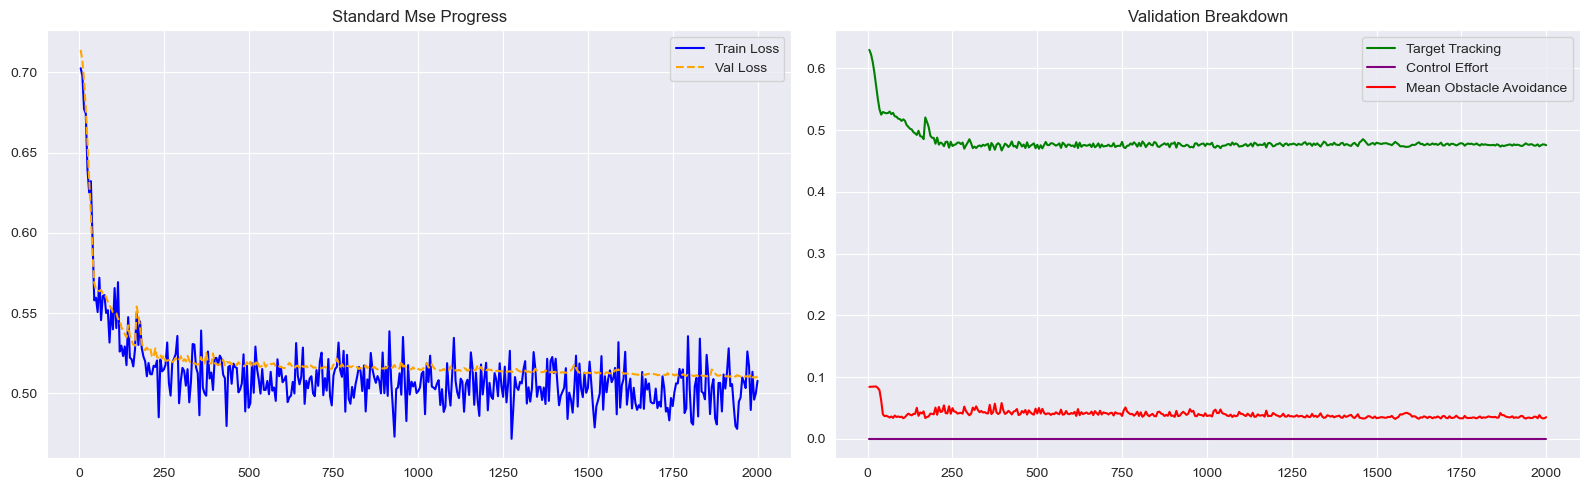

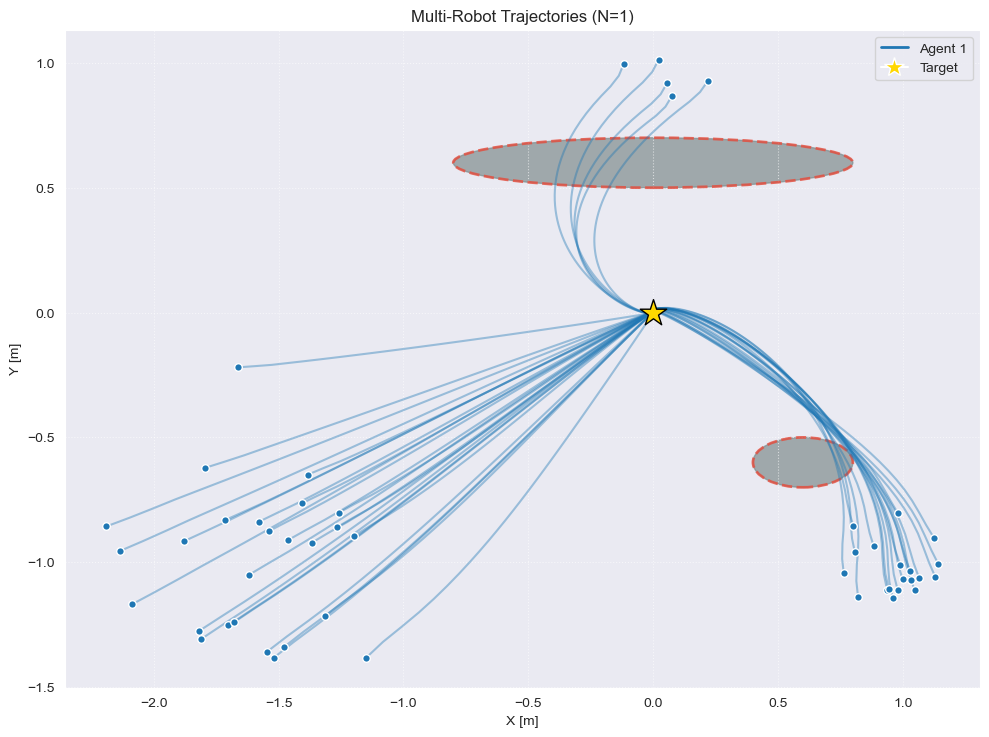

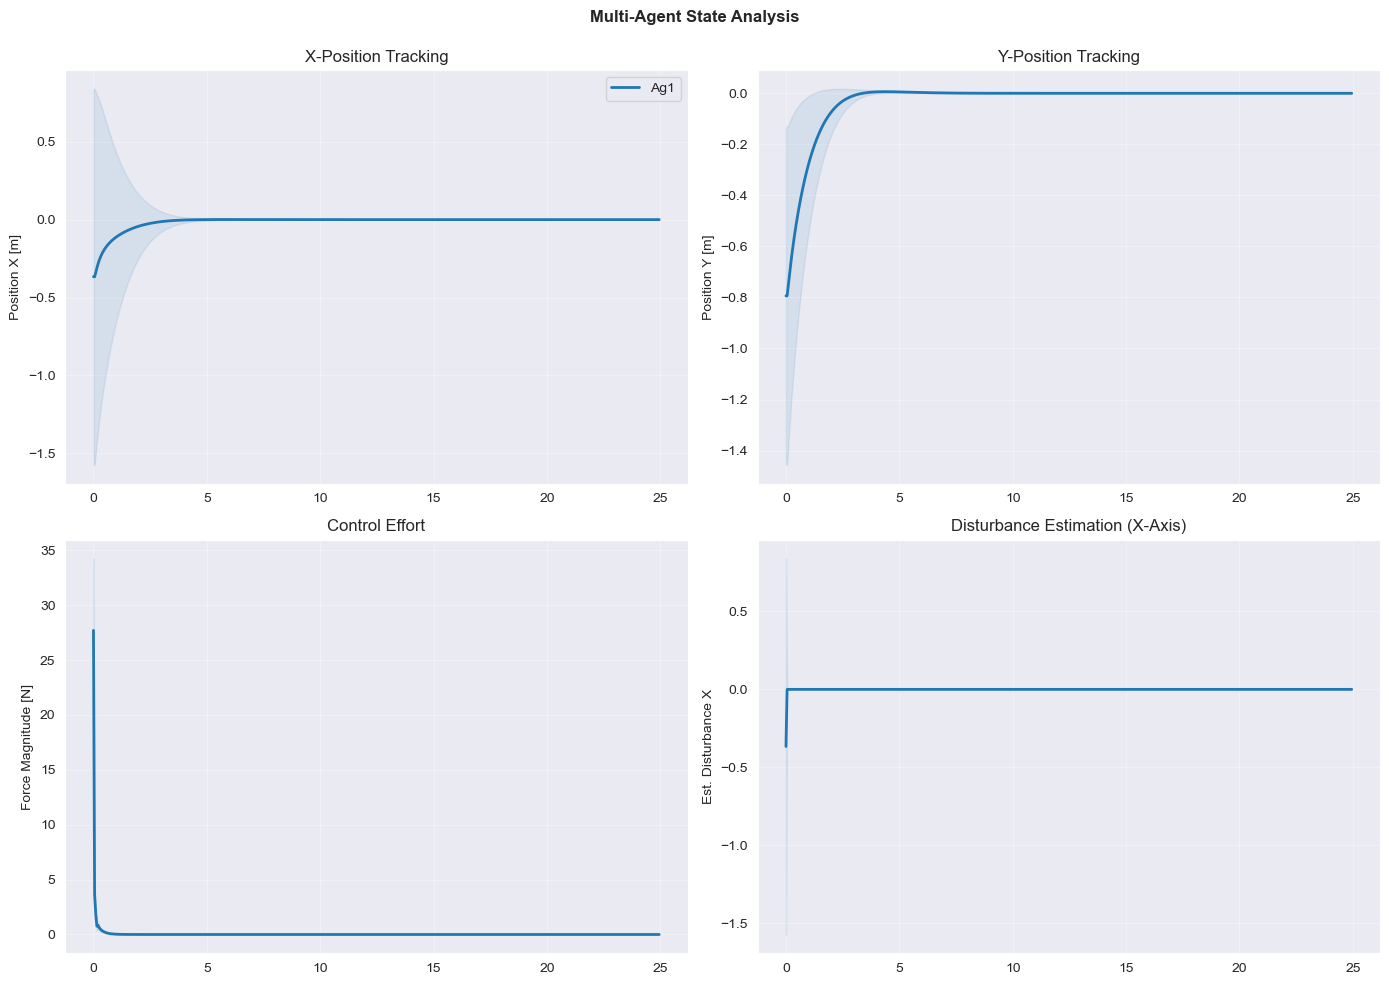

In [7]:
erm_wrapper = ERMWrapper(metric)
history_std_mse, trajs_std_mse = train_agent(
    config=config,
    sim=PB_closed_loop_sim,
    loss_wrapper=erm_wrapper,
    mode="standard_mse",
    fixed_val_w=fixed_val_w,
    generate_random_batch=generate_random_batch,
    plot_results=True,
    plot_kwargs=my_plot_kwargs
)

# Quantile-oriented training

### Define simulated model

In [8]:
#Ren
ren_cvar = ContractiveREN(dim_in=config.state_dim*config.n_agents, dim_out=config.input_dim*config.n_agents, dim_internal=config.dim_internal, dim_nl=config.dim_nl, initialization_std=config.initialization_std).to(config.device)

#Closed loop of Performance boosting controller and simulator of closed loop
PB_closed_loop_sim_cvar = PBClosedLoop(ren_cvar, f_sim, f_nom).to(config.device)

### Training loop

Starting STANDARD_CVAR online training on cpu...


Standard Cvar:   0%|          | 0/2000 [00:00<?, ?it/s]


Restored best model (Metric: 0.5310).


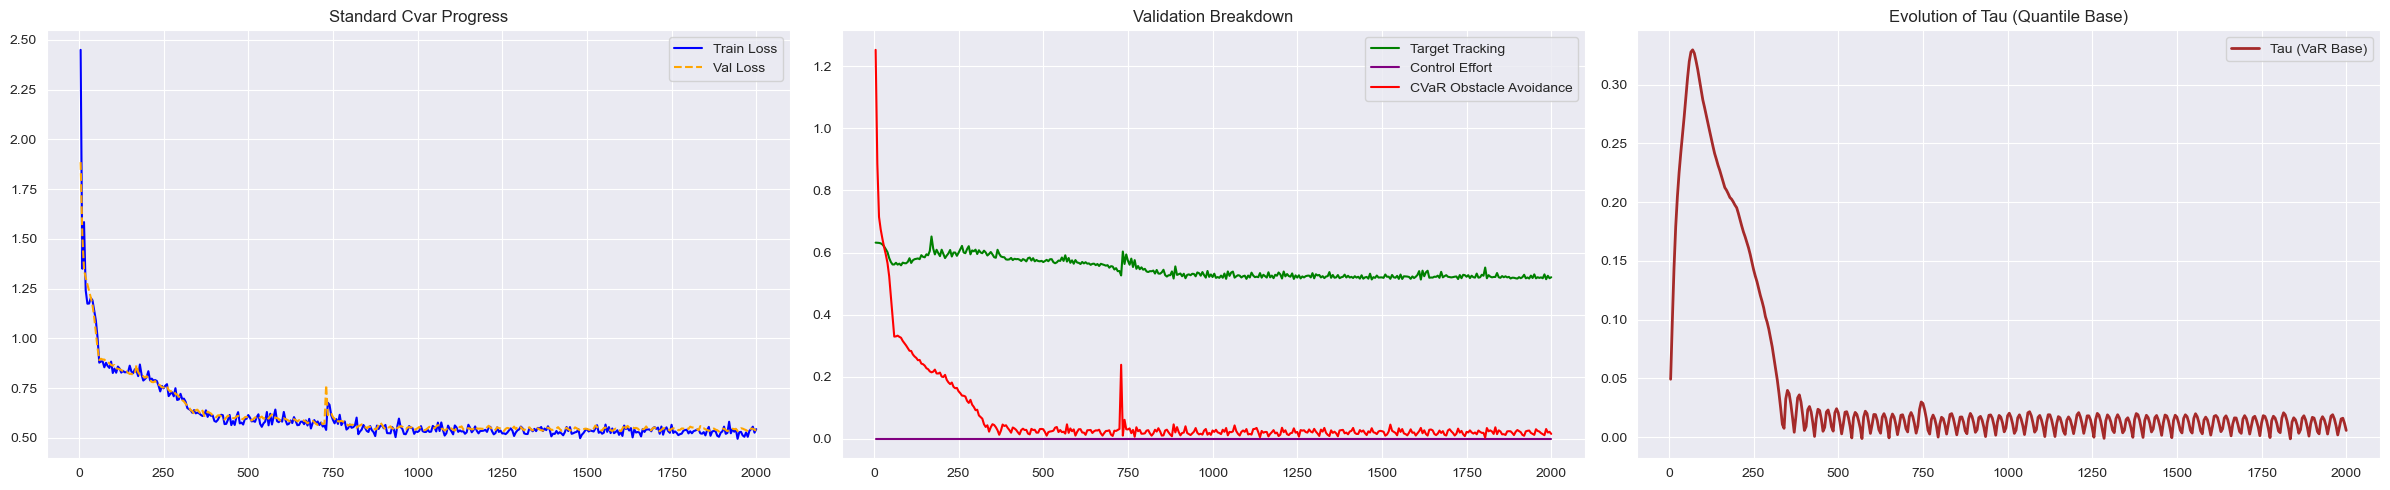

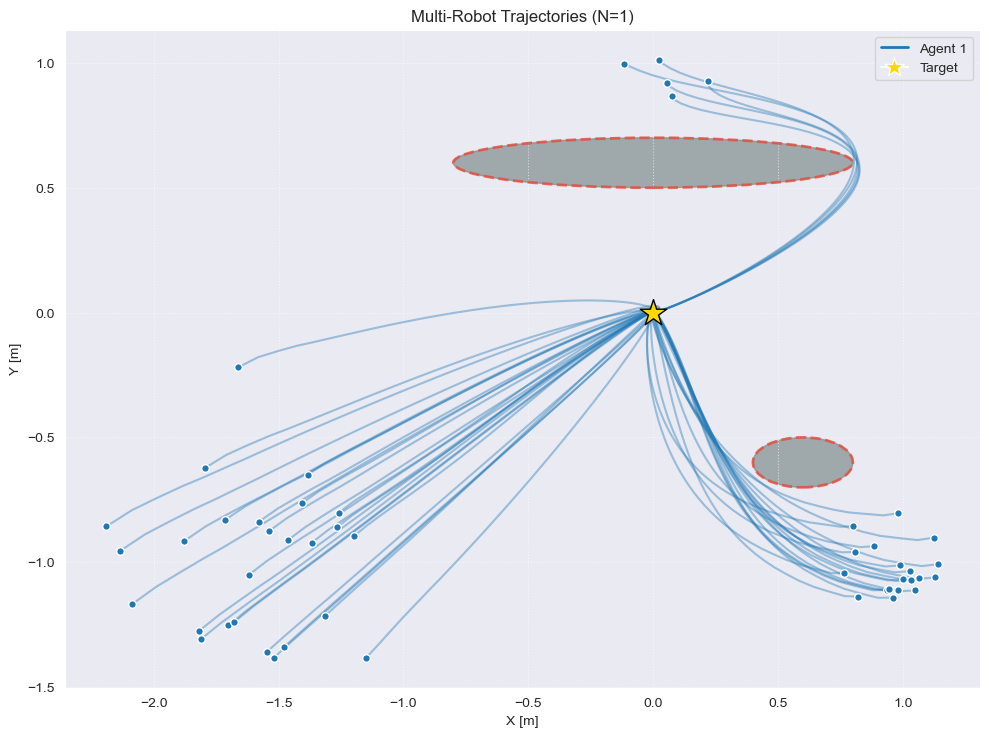

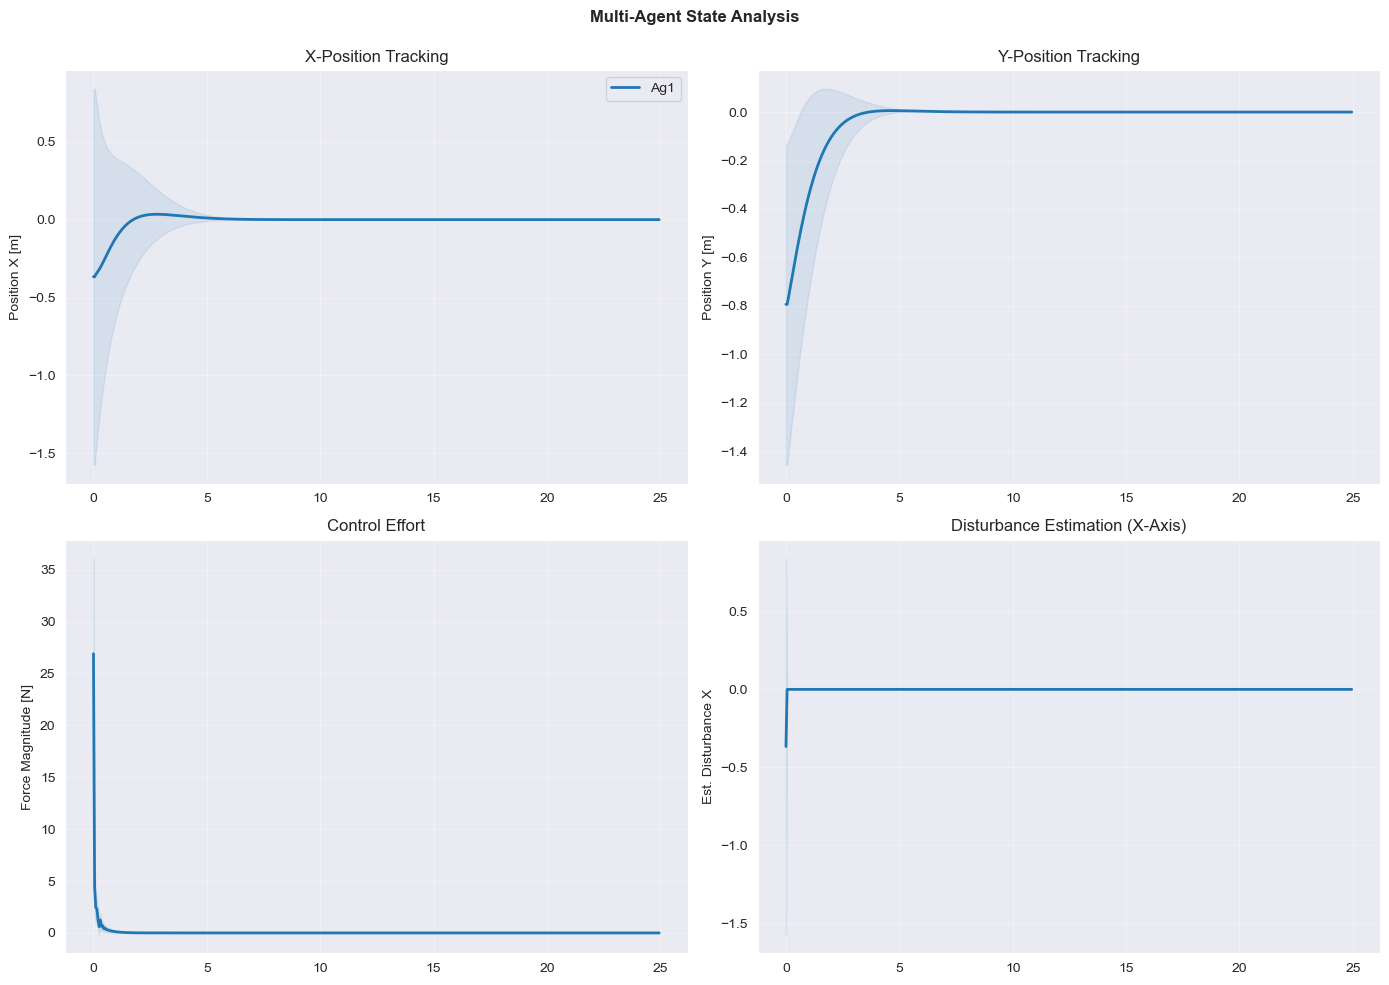

In [9]:
# Use SplitCVaRLossWrapper if decoupled_metrics is True, else CVaRLossWrapper
cvar_wrapper = SplitCVaRLossWrapper(alpha=config.alpha_train, metric=metric, lambda_decoupling=config.lambda_decoupling)
cvar_wrapper.to(config.device)

history_std_cvar, trajs_std_cvar = train_agent(
    config=config,
    sim=PB_closed_loop_sim_cvar,
    loss_wrapper=cvar_wrapper,
    mode="standard_cvar",
    fixed_val_w=fixed_val_w,
    generate_random_batch=generate_random_batch,
    plot_results=True,
    plot_kwargs=my_plot_kwargs
)

# ERM training with Lagrangian

### Define simulated model

In [10]:
#Ren
ren_lagrangian_ERM = ContractiveREN(dim_in=config.state_dim*config.n_agents, dim_out=config.input_dim*config.n_agents, dim_internal=config.dim_internal, dim_nl=config.dim_nl, initialization_std=config.initialization_std).to(config.device)

#Closed loop of Performance boosting controller and simulator of closed loop
PB_closed_loop_sim_lagrangian_ERM = PBClosedLoop(ren_lagrangian_ERM, f_sim, f_nom).to(config.device)

### Training loop


Starting LAGRANGIAN_MSE online training on cpu...


Lagrangian Mse:   0%|          | 0/2000 [00:00<?, ?it/s]


Restored best model (Metric: 6069.7901).


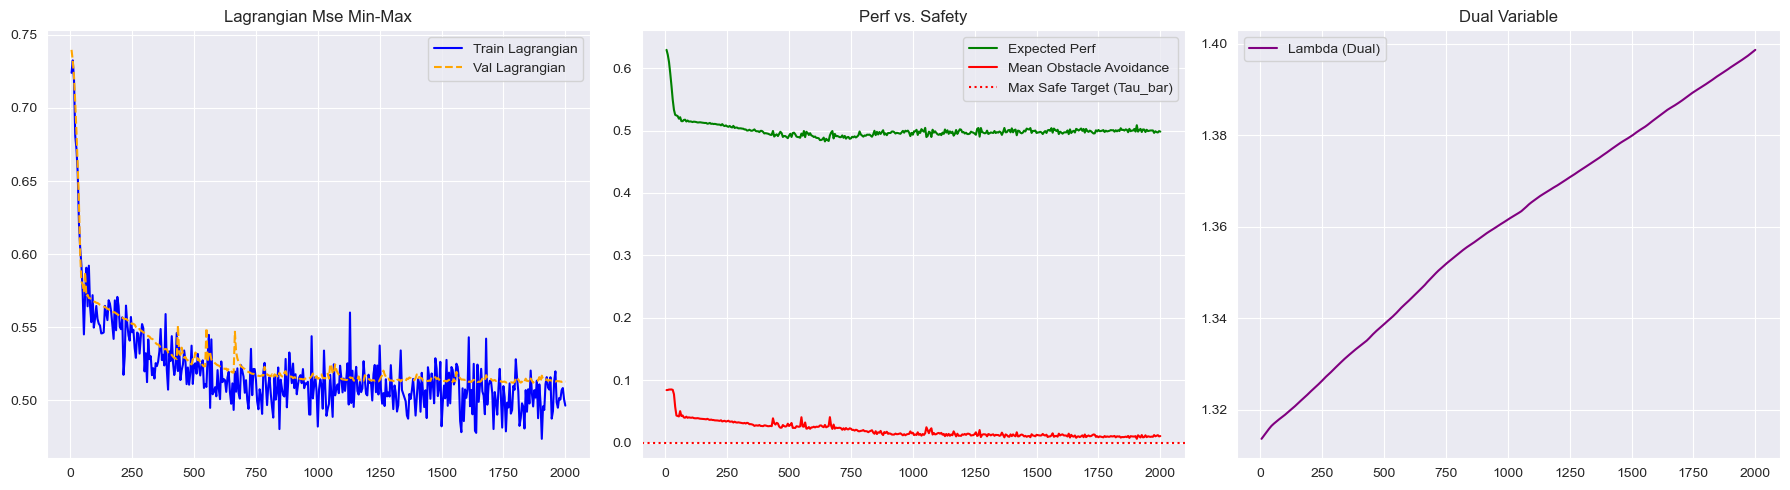

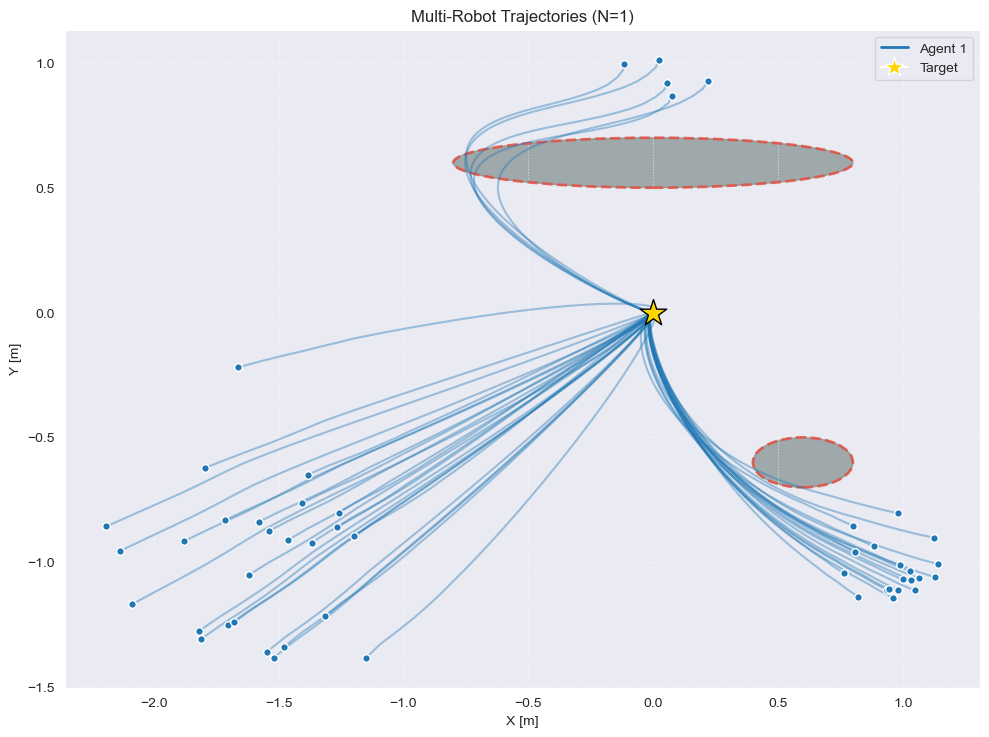

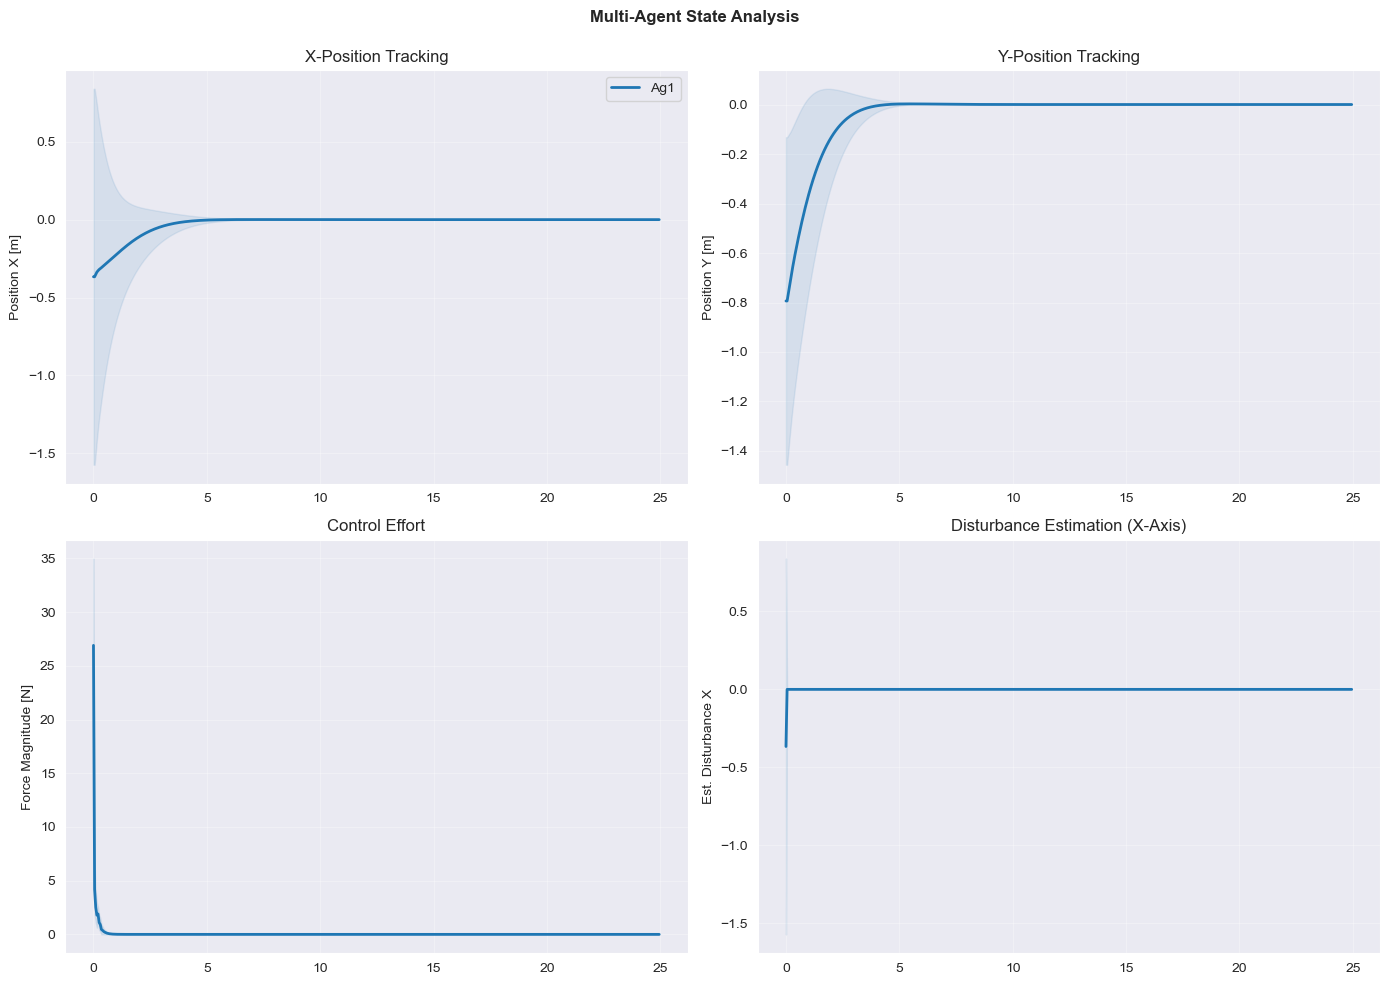

In [11]:
lag_erm_wrapper = LagrangianERMLossWrapper(
    alpha=config.alpha_train,
    tau_safe_bar=config.tau_safe_bar,
    metric=metric
)
lag_erm_wrapper.to(config.device)

history_lag_mse, trajs_lag_mse = train_agent(
    config=config,
    sim=PB_closed_loop_sim_lagrangian_ERM,
    loss_wrapper=lag_erm_wrapper,
    mode="lagrangian_mse",
    fixed_val_w=fixed_val_w,
    generate_random_batch=generate_random_batch,
    plot_results=True,
    plot_kwargs=my_plot_kwargs
)

# Quantile Training with Lagrangian

### Define simulated model


In [12]:
#Ren
ren_lagrangian_cvar = ContractiveREN(dim_in=config.state_dim*config.n_agents, dim_out=config.input_dim*config.n_agents, dim_internal=config.dim_internal, dim_nl=config.dim_nl, initialization_std=config.initialization_std).to(config.device)

#Closed loop of Performance boosting controller and simulator of closed loop
PB_closed_loop_sim_lagrangian_cvar = PBClosedLoop(ren_lagrangian_cvar, f_sim, f_nom).to(config.device)

### Training loop

Starting LAGRANGIAN_CVAR online training on cpu...


Lagrangian Cvar:   0%|          | 0/2000 [00:00<?, ?it/s]


Restored best model (Metric: 10880.6555).


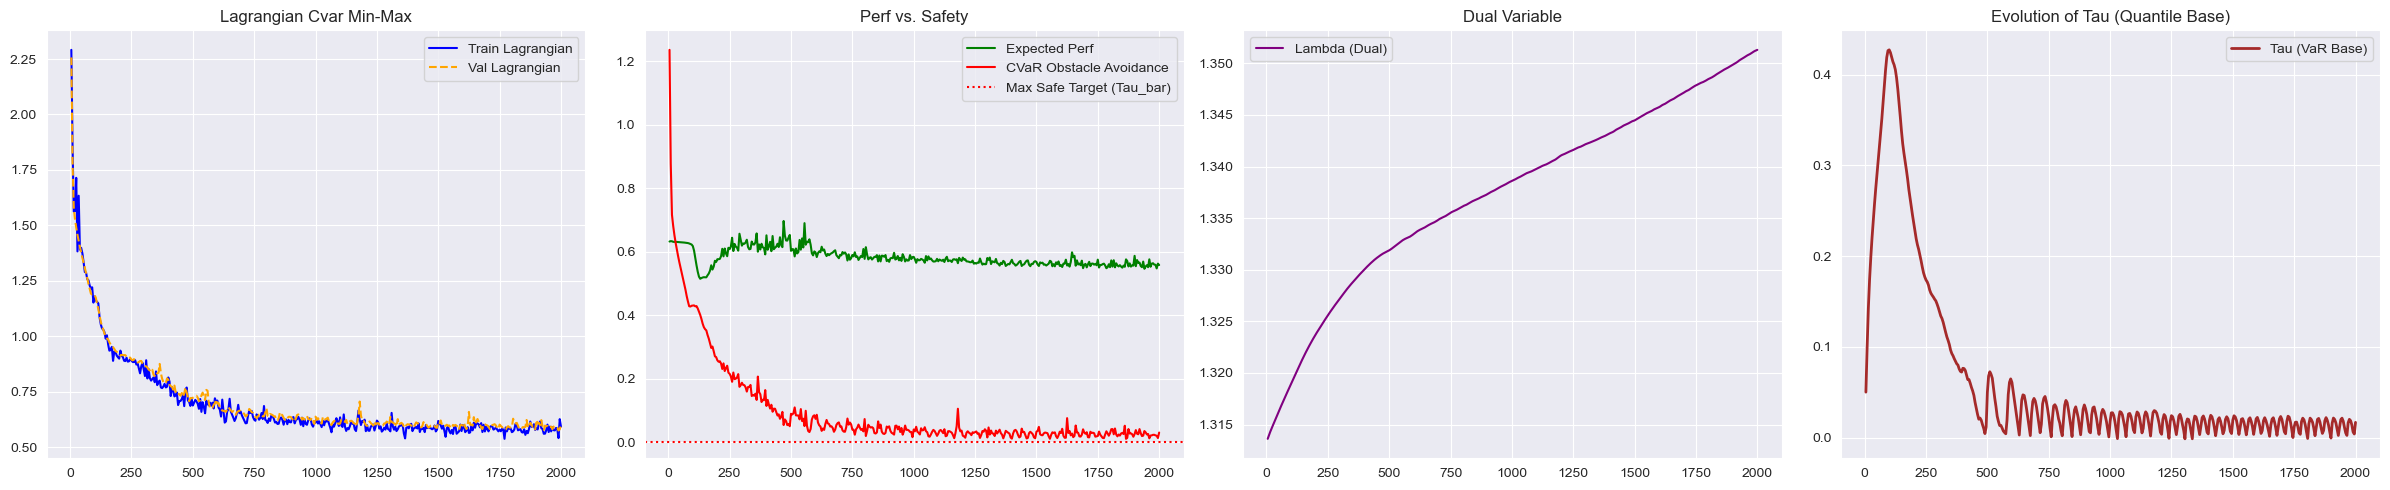

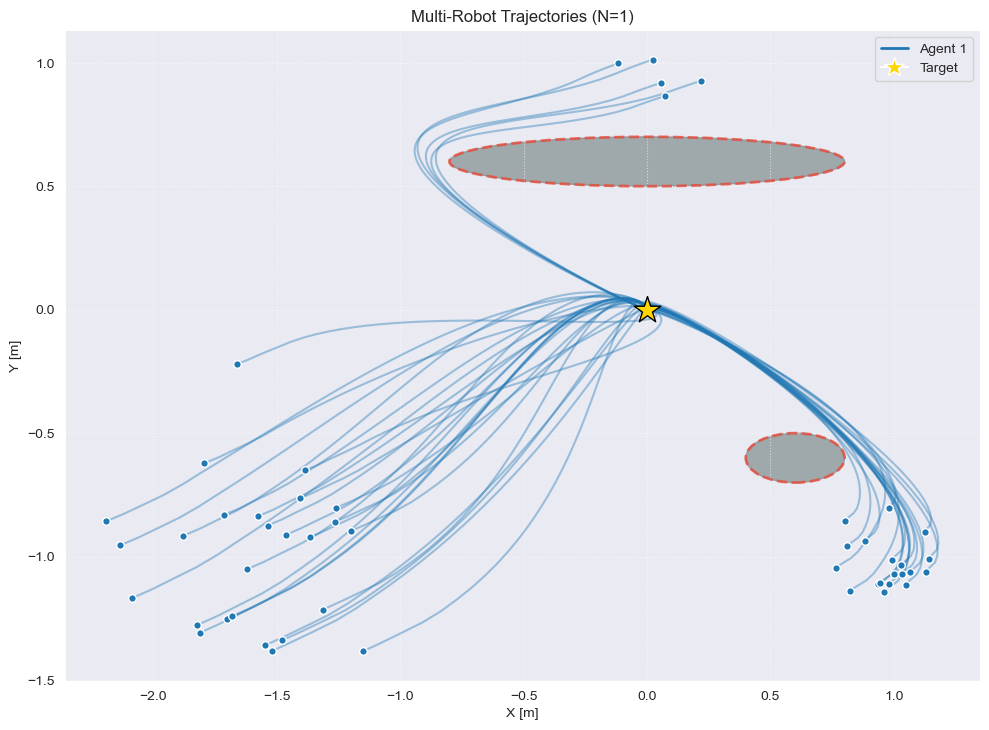

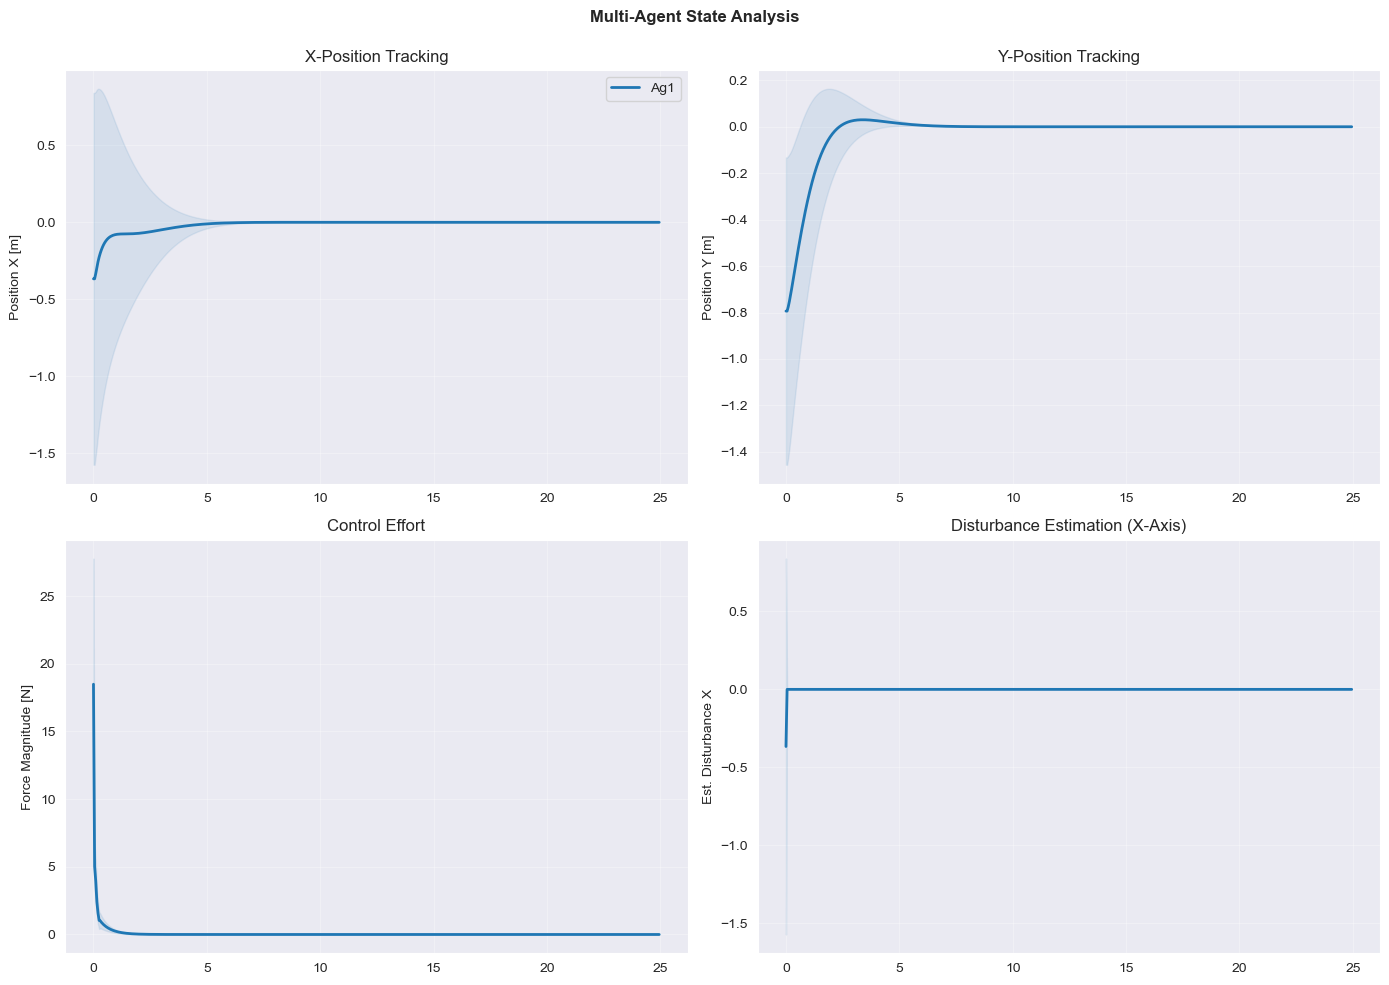

In [13]:
lag_cvar_wrapper = LagrangianCVaRLossWrapper(
    alpha=config.alpha_train,
    tau_safe_bar=config.tau_safe_bar,
    metric=metric
)
lag_cvar_wrapper.to(config.device)

history_lag_cvar, trajs_lag_cvar = train_agent(
    config=config,
    sim=PB_closed_loop_sim_lagrangian_cvar,
    loss_wrapper=lag_cvar_wrapper,
    mode="lagrangian_cvar",
    fixed_val_w=fixed_val_w,
    generate_random_batch=generate_random_batch,
    plot_results=True,
    plot_kwargs=my_plot_kwargs
)

## Comparison test


--- Standard (Average) Controller Total cost ---
Mean Cost:       0.5031
95% Quantile:    0.8595
CVaR (Worst 5%): 0.9601
Absolute Worst:  1.2469

--- Standard (Average) Controller Collision avoidance cost ---
Mean Cost:       0.0326
95% Quantile:    0.2824
CVaR (Worst 5%): 0.3208
Absolute Worst:  0.4441

--- Robust (CVaR) Controller ---
Mean Cost:       0.5146
95% Quantile:    0.8617
CVaR (Worst 5%): 0.9631
Absolute Worst:  1.2529

--- Robust (CVaR) Controller Collision avoidance cost ---
Mean Cost:       0.0004
95% Quantile:    0.0000
CVaR (Worst 5%): 0.0004
Absolute Worst:  0.0683

--- Lagrangian Standard (Average) Controller Total cost ---
Mean Cost:       0.5081
95% Quantile:    0.8628
CVaR (Worst 5%): 0.9630
Absolute Worst:  1.2510

--- Lagrangian Standard (Average) Controller Collision avoidance cost ---
Mean Cost:       0.0058
95% Quantile:    0.0414
CVaR (Worst 5%): 0.0738
Absolute Worst:  0.3143

--- Lagrangian Robust (CVaR) Controller ---
Mean Cost:       0.5699
95% Quantile:

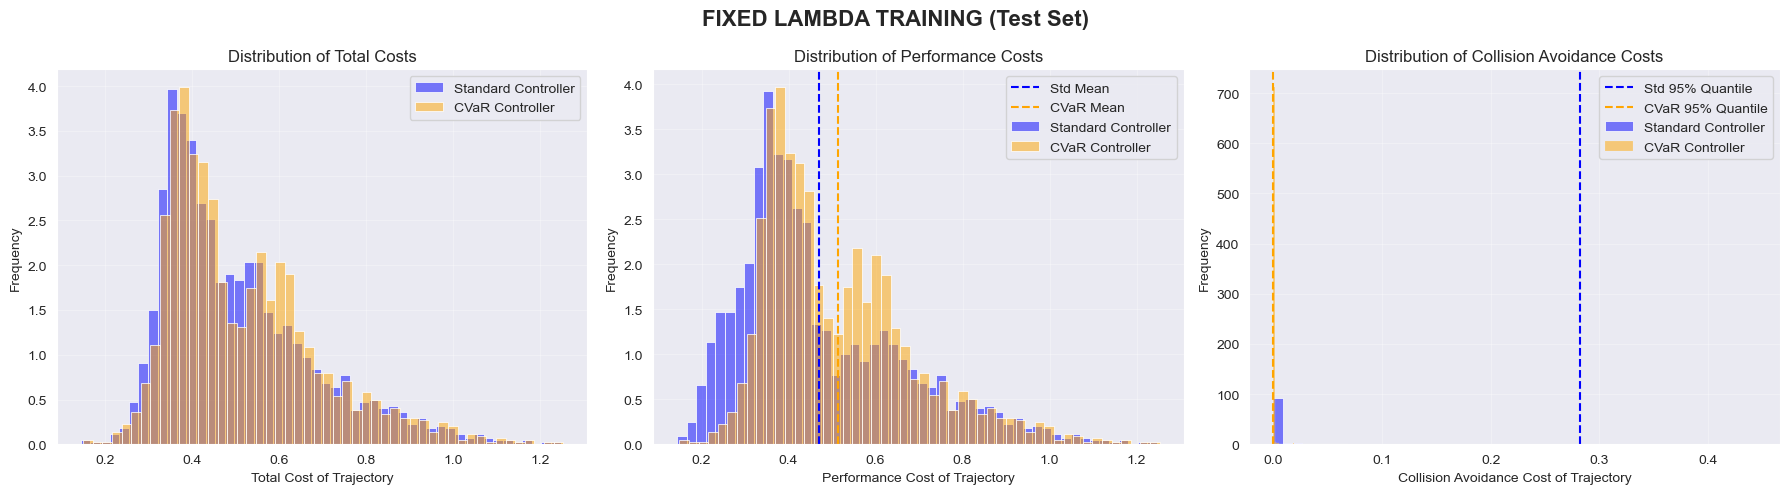

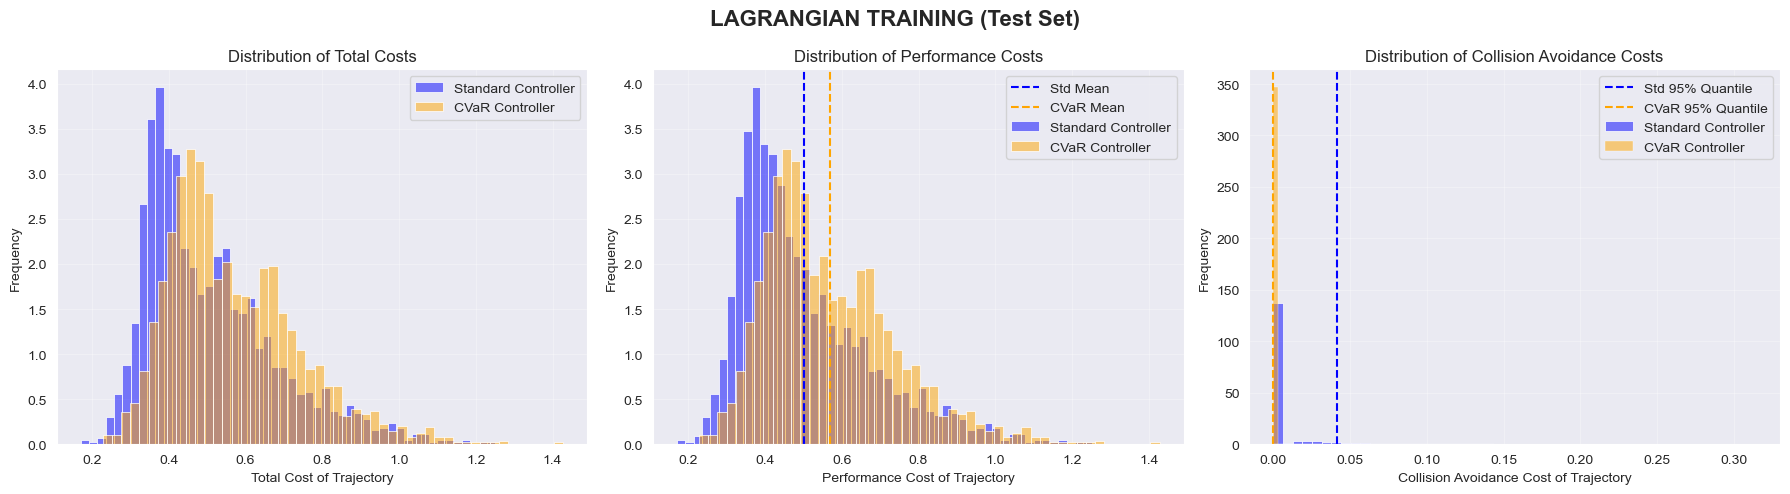

In [15]:
# 2. Evaluate Standard Controller ERM
PB_closed_loop_sim.eval()
with torch.no_grad():
    traj_x_std, traj_u_std, _ = PB_closed_loop_sim.run(test_w)
    # Get the vector of costs (one per trajectory)
    costs_std, costs_std_x, costs_std_u, costs_std_coll = metric(traj_x_std, traj_u_std)
    costs_std = costs_std.cpu().numpy()
    costs_std_coll = costs_std_coll.cpu().numpy()
    costs_std_perf = (costs_std_x + costs_std_u).cpu().numpy()
# 3. Evaluate Controller CVaR
PB_closed_loop_sim_cvar.eval()
with torch.no_grad():
    traj_x_cvar, traj_u_cvar, _ = PB_closed_loop_sim_cvar.run(test_w)
    costs_cvar, costs_cvar_x, costs_cvar_u, costs_cvar_coll = metric(traj_x_cvar, traj_u_cvar)
    costs_cvar = costs_cvar.cpu().numpy()
    costs_cvar_coll = costs_cvar_coll.cpu().numpy()
    costs_cvar_perf = (costs_cvar_x + costs_cvar_u).cpu().numpy()
# 3. Evaluate lagrangian Controller ERM
PB_closed_loop_sim_lagrangian_ERM.eval()
with torch.no_grad():
    traj_x_lag_ERM, traj_u_lag_ERM, traj_w_hat_lag_ERM = PB_closed_loop_sim_lagrangian_ERM.run(test_w)
    costs_lag_ERM, costs_lag_x_ERM, costs_lag_u_ERM, costs_lag_coll_ERM = metric(traj_x_lag_ERM, traj_u_lag_ERM)
    costs_lag_ERM = costs_lag_ERM.cpu().numpy()
    costs_lag_coll_ERM = costs_lag_coll_ERM.cpu().numpy()
    costs_lag_perf_ERM = (costs_lag_x_ERM + costs_lag_u_ERM).cpu().numpy()
# 4. Evaluate lagrangian Controller CVaR
PB_closed_loop_sim_lagrangian_cvar.eval()
with torch.no_grad():
    traj_x_lag, traj_u_lag, traj_w_hat_lag = PB_closed_loop_sim_lagrangian_cvar.run(test_w)
    costs_lag, costs_lag_x, costs_lag_u, costs_lag_coll = metric(traj_x_lag, traj_u_lag)
    costs_lag = costs_lag.cpu().numpy()
    costs_lag_coll = costs_lag_coll.cpu().numpy()
    costs_lag_perf = (costs_lag_x + costs_lag_u).cpu().numpy()

#Compute hard metrics
def print_metrics(name, costs, alpha=0.05):
    mean_cost = np.mean(costs)
    max_cost = np.max(costs)
    # The value below which 95% of the data falls
    quantile_95 = np.quantile(costs, 1 - alpha)
    # Average of the worst 5%
    cvar_95 = np.mean(costs[costs >= quantile_95])

    print(f"--- {name} ---")
    print(f"Mean Cost:       {mean_cost:.4f}")
    print(f"95% Quantile:    {quantile_95:.4f}")

    print(f"CVaR (Worst 5%): {cvar_95:.4f}")
    print(f"Absolute Worst:  {max_cost:.4f}\n")

print_metrics("Standard (Average) Controller Total cost", costs_std)
print_metrics("Standard (Average) Controller Collision avoidance cost", costs_std_coll)
print_metrics("Robust (CVaR) Controller", costs_cvar)
print_metrics("Robust (CVaR) Controller Collision avoidance cost", costs_cvar_coll)

print_metrics("Lagrangian Standard (Average) Controller Total cost", costs_lag_ERM)
print_metrics("Lagrangian Standard (Average) Controller Collision avoidance cost", costs_lag_coll_ERM)

print_metrics("Lagrangian Robust (CVaR) Controller", costs_lag)
print_metrics("Lagrangian Robust (CVaR) Controller Collision avoidance cost", costs_lag_coll)

# ==============================================================================
# 1. COMPARE ERM AND CVAR TRAINING WITH FIXED LAMBDA
# ==============================================================================
fig1, axes1 = plt.subplots(1, 3, figsize=(18, 5))
fig1.suptitle("FIXED LAMBDA TRAINING (Test Set)", fontsize=16, fontweight='bold')

# --- Subplot 1: Total Costs ---
sns.histplot(costs_std, color='blue', alpha=0.5, label='Standard Controller', bins=50, stat='density', ax=axes1[0])
sns.histplot(costs_cvar, color='orange', alpha=0.5, label='CVaR Controller', bins=50, stat='density', ax=axes1[0])
axes1[0].set_title("Distribution of Total Costs")
axes1[0].set_xlabel("Total Cost of Trajectory")
axes1[0].set_ylabel("Frequency")
axes1[0].legend()
axes1[0].grid(True, alpha=0.3)

# --- Subplot 2: Performance Costs ---
sns.histplot(costs_std_perf, color='blue', alpha=0.5, label='Standard Controller', bins=50, stat='density', ax=axes1[1])
sns.histplot(costs_cvar_perf, color='orange', alpha=0.5, label='CVaR Controller', bins=50, stat='density', ax=axes1[1])
axes1[1].axvline(np.mean(costs_std_perf), color='blue', linestyle='dashed', label='Std Mean')
axes1[1].axvline(np.mean(costs_cvar_perf), color='orange', linestyle='dashed', label='CVaR Mean')
axes1[1].set_title("Distribution of Performance Costs")
axes1[1].set_xlabel("Performance Cost of Trajectory")
axes1[1].set_ylabel("Frequency")
axes1[1].legend()
axes1[1].grid(True, alpha=0.3)

# --- Subplot 3: Collision Costs ---
sns.histplot(costs_std_coll, color='blue', alpha=0.5, label='Standard Controller', bins=50, stat='density', ax=axes1[2])
sns.histplot(costs_cvar_coll, color='orange', alpha=0.5, label='CVaR Controller', bins=50, stat='density', ax=axes1[2])
axes1[2].axvline(np.quantile(costs_std_coll, 0.95), color='blue', linestyle='dashed', label='Std 95% Quantile')
axes1[2].axvline(np.quantile(costs_cvar_coll, 0.95), color='orange', linestyle='dashed', label='CVaR 95% Quantile')
axes1[2].set_title("Distribution of Collision Avoidance Costs")
axes1[2].set_xlabel("Collision Avoidance Cost of Trajectory")
axes1[2].set_ylabel("Frequency")
axes1[2].legend()
axes1[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


# ==============================================================================
# 2. COMPARE ERM AND CVAR TRAINING WITH LAGRANGIAN
# ==============================================================================
fig2, axes2 = plt.subplots(1, 3, figsize=(18, 5))
fig2.suptitle("LAGRANGIAN TRAINING (Test Set)", fontsize=16, fontweight='bold')

# --- Subplot 1: Total Costs ---
# Note: I changed costs_lag_perf_ERM/costs_lag_perf to costs_lag_ERM/costs_lag here
# assuming these are your total cost variables. Change them back if needed!
sns.histplot(costs_lag_ERM, color='blue', alpha=0.5, label='Standard Controller', bins=50, stat='density', ax=axes2[0])
sns.histplot(costs_lag, color='orange', alpha=0.5, label='CVaR Controller', bins=50, stat='density', ax=axes2[0])
axes2[0].set_title("Distribution of Total Costs")
axes2[0].set_xlabel("Total Cost of Trajectory")
axes2[0].set_ylabel("Frequency")
axes2[0].legend()
axes2[0].grid(True, alpha=0.3)

# --- Subplot 2: Performance Costs ---
sns.histplot(costs_lag_perf_ERM, color='blue', alpha=0.5, label='Standard Controller', bins=50, stat='density', ax=axes2[1])
sns.histplot(costs_lag_perf, color='orange', alpha=0.5, label='CVaR Controller', bins=50, stat='density', ax=axes2[1])
axes2[1].axvline(np.mean(costs_lag_perf_ERM), color='blue', linestyle='dashed', label='Std Mean')
axes2[1].axvline(np.mean(costs_lag_perf), color='orange', linestyle='dashed', label='CVaR Mean')
axes2[1].set_title("Distribution of Performance Costs")
axes2[1].set_xlabel("Performance Cost of Trajectory")
axes2[1].set_ylabel("Frequency")
axes2[1].legend()
axes2[1].grid(True, alpha=0.3)

# --- Subplot 3: Collision Costs ---
sns.histplot(costs_lag_coll_ERM, color='blue', alpha=0.5, label='Standard Controller', bins=50, stat='density', ax=axes2[2])
sns.histplot(costs_lag_coll, color='orange', alpha=0.5, label='CVaR Controller', bins=50, stat='density', ax=axes2[2])
axes2[2].axvline(np.quantile(costs_lag_coll_ERM, 0.95), color='blue', linestyle='dashed', label='Std 95% Quantile')
axes2[2].axvline(np.quantile(costs_lag_coll, 0.95), color='orange', linestyle='dashed', label='CVaR 95% Quantile')
axes2[2].set_title("Distribution of Collision Avoidance Costs")
axes2[2].set_xlabel("Collision Avoidance Cost of Trajectory")
axes2[2].set_ylabel("Frequency")
axes2[2].legend()
axes2[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()